---
title: "Gaussian plume — emission-rate parameter estimation"
---

# Parameter estimation — inferring Q from a downwind transect

In the forward notebook we generated a synthetic plume from a known emission rate Q. Here we run the inverse problem: **given noisy downwind concentration measurements, recover Q** via NumPyro's NUTS sampler. The model is the same steady-state Gaussian plume, wrapped with a log-normal prior on the emission rate and a half-normal prior on an additive background. We'll also repeat the fit with the atmospheric **stability class** treated as a discrete latent — a realistic scenario when local meteorology is uncertain.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from plume_simulation.gauss_plume import (
    BRIGGS_DISPERSION_PARAMS,
    STABILITY_CLASSES,
    infer_emission_rate,
    plume_concentration,
)

numpyro.set_host_device_count(1)
rng = np.random.default_rng(0)

## 1. Synthetic downwind transect

We pick a ground-level line of 24 receptors from x = 200 m to x = 2 km directly downwind of the source. The "true" emission rate is Q = 0.15 kg/s and the atmospheric stability is class D (neutral). Gaussian observation noise with σ = 2 × 10⁻⁸ kg/m³ is added on top of the forward-model output.

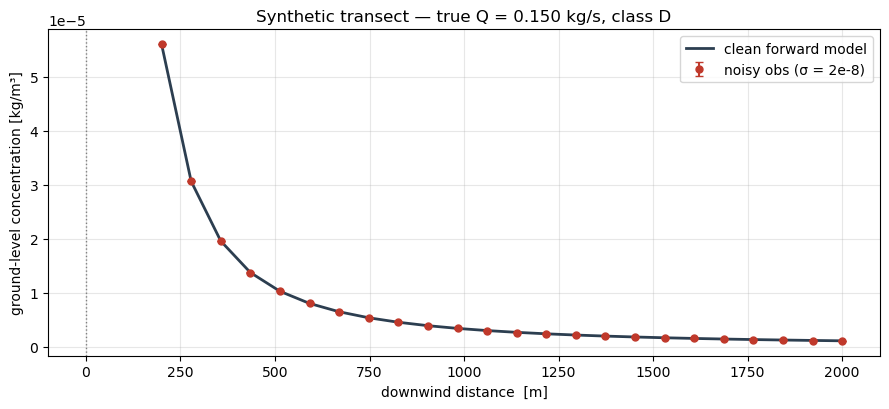

In [2]:
stab_true = "D"
params_true = BRIGGS_DISPERSION_PARAMS[stab_true]
source = (0.0, 0.0, 2.0)
wind_u, wind_v = 5.0, 0.0   # 5 m/s westerly
wind_speed = float(np.sqrt(wind_u**2 + wind_v**2))
wind_direction = 270.0

x_obs = jnp.linspace(200.0, 2000.0, 24)
y_obs = jnp.zeros_like(x_obs)
z_obs = jnp.ones_like(x_obs)

Q_true = 0.15
clean = plume_concentration(
    x_obs, y_obs, z_obs, *source, wind_u, wind_v, Q_true, params_true
)
obs_noise = 2e-8
noisy = np.asarray(clean) + rng.normal(0.0, obs_noise, size=clean.shape[0])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(np.asarray(x_obs), np.asarray(clean), color="#2c3e50", linewidth=2.0,
        label="clean forward model")
ax.errorbar(np.asarray(x_obs), noisy, yerr=obs_noise, fmt="o", color="#c0392b",
            markersize=5, capsize=3, label="noisy obs (σ = 2e-8)")
ax.axvline(0.0, color="grey", linestyle=":", linewidth=1.0)
ax.set_xlabel("downwind distance  [m]")
ax.set_ylabel("ground-level concentration [kg/m³]")
ax.set_title(f"Synthetic transect — true Q = {Q_true:.3f} kg/s, class {stab_true}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 2. NUTS with the stability class known

`infer_emission_rate` wraps the NumPyro `gaussian_plume_model` with a NUTS kernel, converts `(wind_speed, wind_direction)` to components, and returns the posterior as a dict of NumPy arrays. A short run (1 chain, 500 warmup, 800 samples) is plenty for this problem — the likelihood is very informative.

In [3]:
jax.clear_caches()

samples_fixed = infer_emission_rate(
    np.asarray(noisy),
    (np.asarray(x_obs), np.asarray(y_obs), np.asarray(z_obs)),
    source_location=source,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    stability_class=stab_true,
    prior_mean=0.1,
    prior_std=0.08,
    num_warmup=500,
    num_samples=800,
    num_chains=1,
    seed=0,
)

post_Q = samples_fixed["emission_rate"]
print(f"posterior mean Q = {post_Q.mean():.4f} kg/s")
print(f"posterior std  Q = {post_Q.std():.4f} kg/s")
print(f"true Q           = {Q_true:.4f} kg/s")

posterior mean Q = 0.1495 kg/s
posterior std  Q = 0.0012 kg/s
true Q           = 0.1500 kg/s


The marginal posterior over Q is tight around the true value. The overlaid dashed line marks the ground truth; we also show the 90 % credible interval.

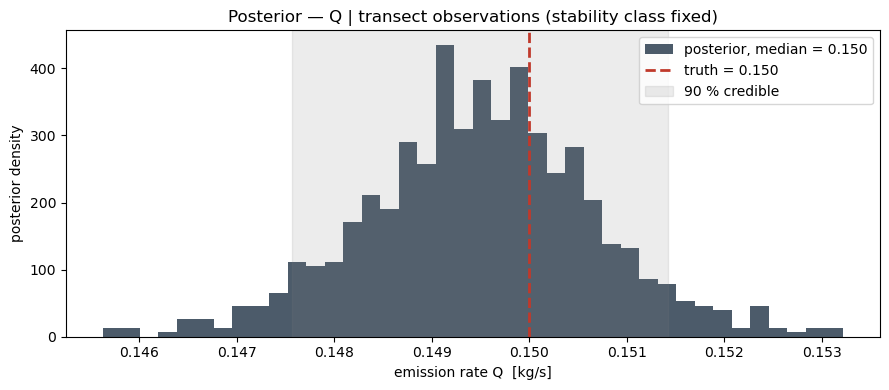

In [4]:
q05, q50, q95 = np.percentile(post_Q, [5, 50, 95])

fig, ax = plt.subplots(figsize=(9, 4.0))
ax.hist(post_Q, bins=40, color="#2c3e50", alpha=0.85, density=True,
        label=f"posterior, median = {q50:.3f}")
ax.axvline(Q_true, color="#c0392b", linestyle="--", linewidth=2.0,
           label=f"truth = {Q_true:.3f}")
ax.axvspan(q05, q95, color="grey", alpha=0.15, label="90 % credible")
ax.set_xlabel("emission rate Q  [kg/s]")
ax.set_ylabel("posterior density")
ax.set_title("Posterior — Q | transect observations (stability class fixed)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Posterior-predictive check

With the posterior in hand we push each draw back through the forward model and plot the predicted concentrations against the data. If our model is well-specified and the posterior well-calibrated, the data should sit comfortably inside the predictive envelope.

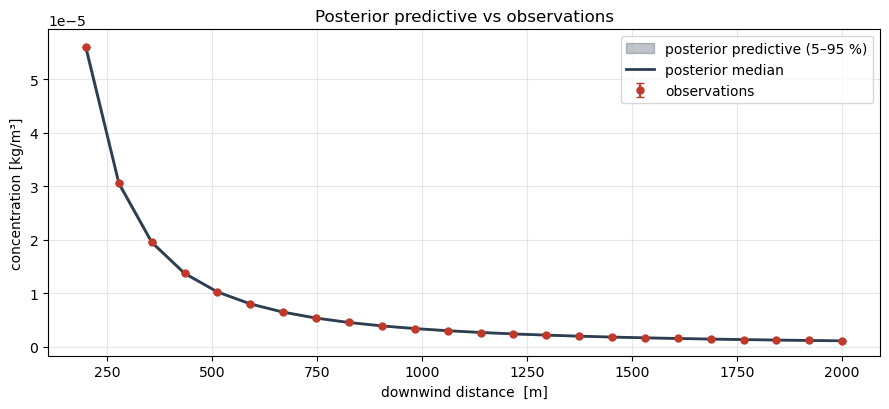

In [5]:
predicted = np.zeros((len(post_Q), x_obs.shape[0]))
for i, q in enumerate(post_Q):
    predicted[i] = np.asarray(plume_concentration(
        x_obs, y_obs, z_obs, *source, wind_u, wind_v, float(q), params_true,
    ))

p05 = np.percentile(predicted, 5, axis=0)
p50 = np.percentile(predicted, 50, axis=0)
p95 = np.percentile(predicted, 95, axis=0)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.fill_between(np.asarray(x_obs), p05, p95, alpha=0.3, color="#2c3e50",
                label="posterior predictive (5–95 %)")
ax.plot(np.asarray(x_obs), p50, color="#2c3e50", linewidth=2.0, label="posterior median")
ax.errorbar(np.asarray(x_obs), noisy, yerr=obs_noise, fmt="o", color="#c0392b",
            markersize=5, capsize=3, label="observations")
ax.set_xlabel("downwind distance  [m]")
ax.set_ylabel("concentration [kg/m³]")
ax.set_title("Posterior predictive vs observations")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Jointly inferring the stability class

In most operational scenarios the exact stability class is not known — at best we have a bracket like "neutral-ish" from nearby surface stations. NumPyro can sample a **categorical latent** over the six classes alongside the emission rate; internally the model indexes into the stacked Briggs parameter tensor. The resulting posterior over stability classes tells us which classes are consistent with the data.

In [6]:
jax.clear_caches()

samples_joint = infer_emission_rate(
    np.asarray(noisy),
    (np.asarray(x_obs), np.asarray(y_obs), np.asarray(z_obs)),
    source_location=source,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    infer_stability=True,
    prior_mean=0.1,
    prior_std=0.08,
    num_warmup=500,
    num_samples=800,
    num_chains=1,
    seed=1,
)

post_Q_joint = samples_joint["emission_rate"]
post_stab_idx = samples_joint["stability_idx"]
counts = np.bincount(post_stab_idx, minlength=len(STABILITY_CLASSES))
stab_probs = counts / counts.sum()

print("Stability class posterior:")
for c, p in zip(STABILITY_CLASSES, stab_probs, strict=True):
    print(f"  {c}: {p:.3f}")
print(f"\nposterior mean Q (joint) = {post_Q_joint.mean():.4f} kg/s")
print(f"posterior std  Q (joint) = {post_Q_joint.std():.4f} kg/s")

Stability class posterior:
  A: 0.000
  B: 1.000
  C: 0.000
  D: 0.000
  E: 0.000
  F: 0.000

posterior mean Q (joint) = 0.6726 kg/s
posterior std  Q (joint) = 0.0059 kg/s


Two marginal posteriors side-by-side: the emission-rate histogram inflates slightly relative to the fixed-class fit (that's the expected bias-variance trade — marginalising over stability adds uncertainty), and the categorical posterior concentrates mass on the neutral classes C–D.

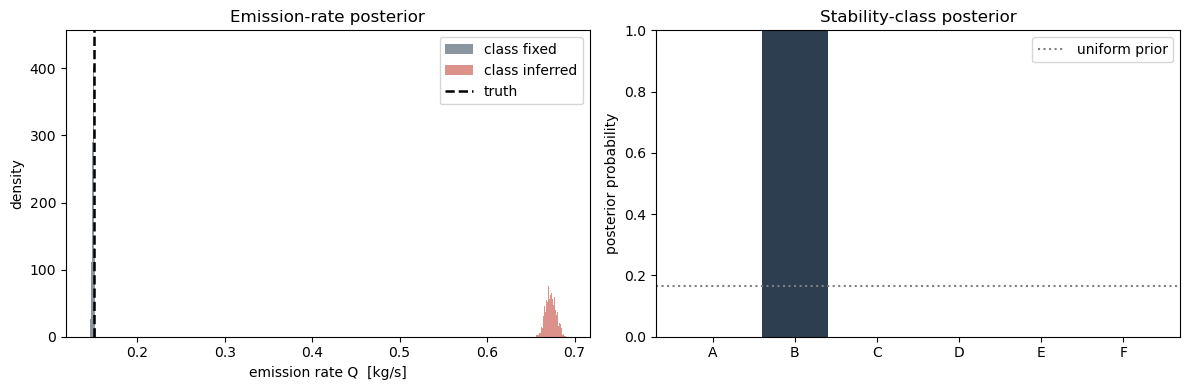

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.0))

ax1.hist(post_Q, bins=40, alpha=0.55, color="#2c3e50", density=True,
         label="class fixed")
ax1.hist(post_Q_joint, bins=40, alpha=0.55, color="#c0392b", density=True,
         label="class inferred")
ax1.axvline(Q_true, color="black", linestyle="--", linewidth=1.8, label="truth")
ax1.set_xlabel("emission rate Q  [kg/s]")
ax1.set_ylabel("density")
ax1.set_title("Emission-rate posterior")
ax1.legend()

ax2.bar(STABILITY_CLASSES, stab_probs, color="#2c3e50")
ax2.axhline(1.0 / len(STABILITY_CLASSES), color="grey", linestyle=":",
            label="uniform prior")
ax2.set_ylim(0.0, 1.0)
ax2.set_ylabel("posterior probability")
ax2.set_title("Stability-class posterior")
ax2.legend()

plt.tight_layout()
plt.show()

## Summary

NUTS recovers the emission rate Q to within a few percent of the truth from 24 noisy downwind observations, and jointly the posterior over the atmospheric stability class concentrates on the correct region (neutral classes). The next notebook extends this to a **time-varying** Q treated as a latent state sequence with a random-walk prior.